In [35]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
np.random.seed(42)
df_cnc = pd.DataFrame({     
"spindle_pressure": np.random.normal(100, 5, 100),
    
"spindle_temp": np.random.normal(65,3,100),
"vibration": np.random.normal(0.5,0.1,100)
})

In [37]:
df_cnc.loc[30, "spindle_pressure"] = 145
df_cnc.loc[55, "spindle_temp"] = 92
df_cnc.loc[78, "vibration"] = 1.8

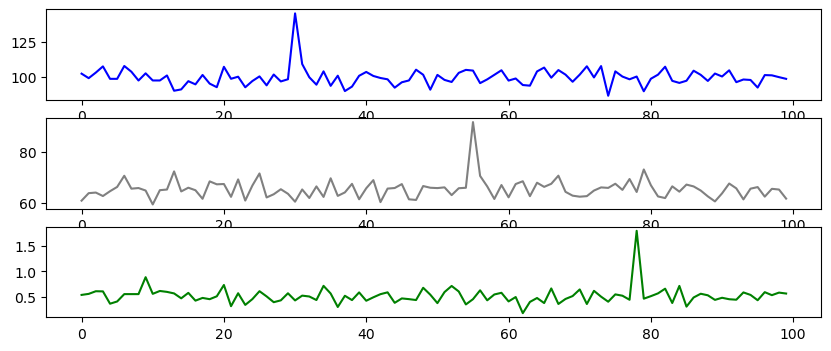

In [38]:
fig, axes = plt.subplots(3,1, figsize=(10,4)) 
axes[0].plot(df_cnc.index,df_cnc["spindle_pressure"],color="blue") 
axes[1].plot(df_cnc.index,df_cnc["spindle_temp"],color="grey") 
axes[2].plot(df_cnc.index,df_cnc["vibration"],color="green")
plt.savefig("cnc_overview.png") 
plt.show()

In [39]:
anomalies = detect_anomalies(df_cnc, "spindle_pressure")

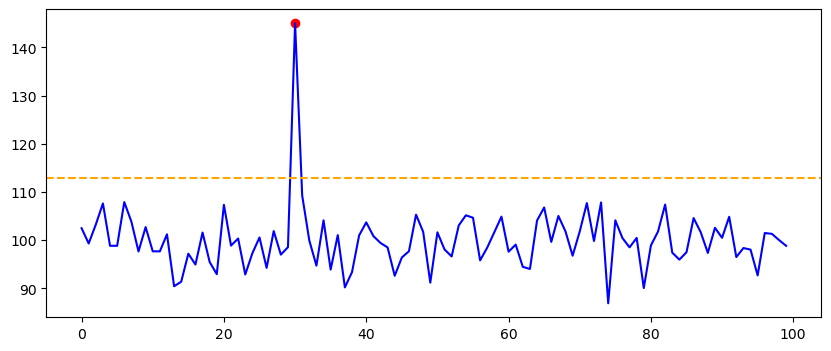

In [40]:
fig, axes=plt.subplots(1,1,figsize=(10,4))
axes.plot(df_cnc.index,df_cnc["spindle_pressure"],color="blue")
axes.scatter(anomalies.index,anomalies["spindle_pressure"],color="red")
axes.axhline(y=threshold,color="orange",linestyle="--")
plt.savefig("anomolies_plot.png")
plt.show()

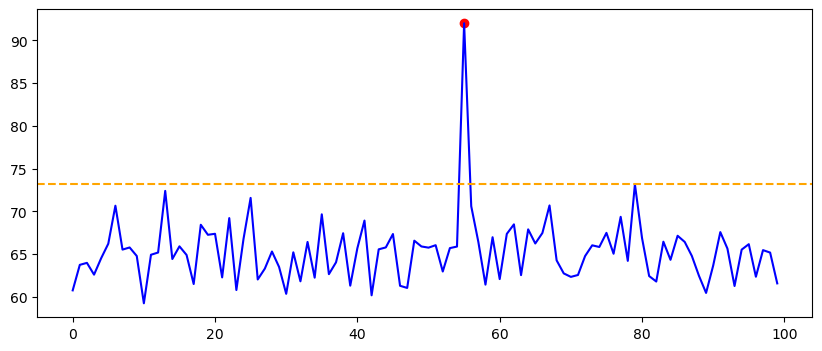

In [41]:
anomalies = detect_anomalies(df_cnc, "spindle_temp")
fig,axes=plt.subplots(1,1,figsize=(10,4))
axes.plot(df_cnc.index, df_cnc["spindle_temp"],color="blue")
axes.scatter(anomalies_temp.index, anomalies_temp["spindle_temp"],color="red")
axes.axhline(threshold_temp,color="orange",linestyle="--")
plt.savefig("anomalies_temp_plot.png")
plt.show()

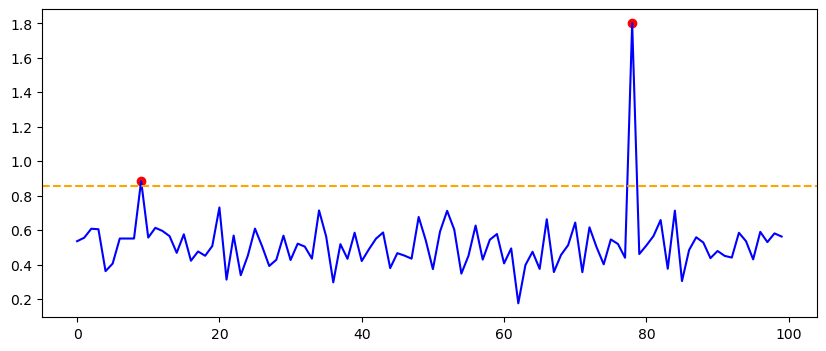

In [42]:
anomalies = detect_anomalies(df_cnc, "vibration")
fig,axes=plt.subplots(1,1,figsize=(10,4))
axes.plot(df_cnc.index, df_cnc["vibration"],color="blue")
axes.scatter(anomalies_vibration.index, anomalies_vibration["vibration"],color="red")
axes.axhline(threshold_vib,color="orange",linestyle="--")
plt.savefig("anomalies_vibration_plot.png")
plt.show()

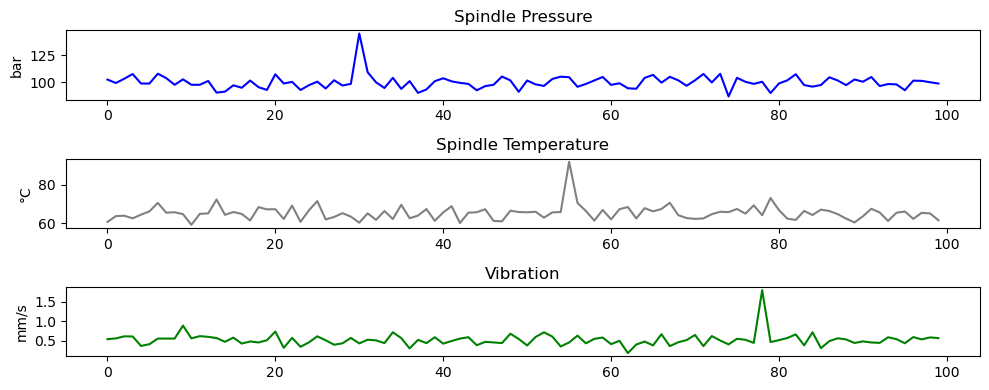

In [43]:
fig, axes = plt.subplots(3, 1, figsize=(10, 4))
axes[0].plot(df_cnc.index, df_cnc["spindle_pressure"], color="blue")
axes[0].set_title("Spindle Pressure")
axes[0].set_ylabel("bar")
axes[1].plot(df_cnc.index, df_cnc["spindle_temp"], color="grey")
axes[1].set_title("Spindle Temperature")
axes[1].set_ylabel("°C")
axes[2].plot(df_cnc.index, df_cnc["vibration"], color="green")
axes[2].set_title("Vibration")
axes[2].set_ylabel("mm/s")
plt.tight_layout()
plt.savefig("cnc_overview.png")
plt.show()

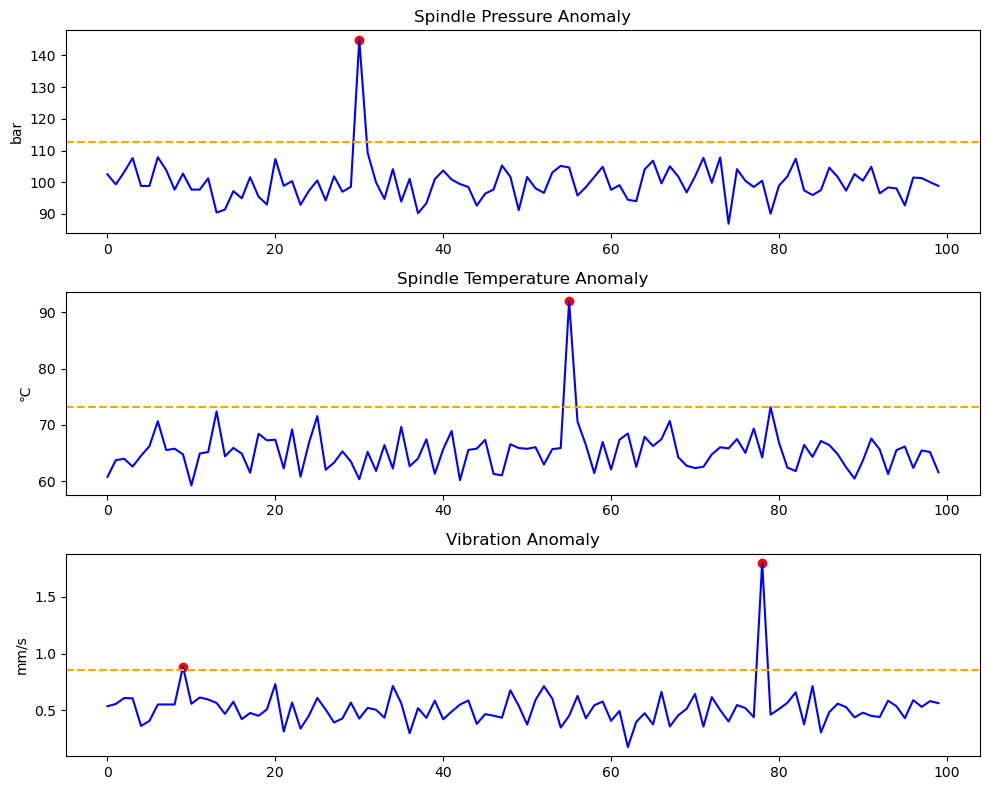

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

mean_p = df_cnc["spindle_pressure"].mean()
std_p = df_cnc["spindle_pressure"].std()
threshold = mean_p + 2 * std_p
anomalies = df_cnc[df_cnc["spindle_pressure"] > threshold]
axes[0].plot(df_cnc.index, df_cnc["spindle_pressure"], color="blue")
axes[0].scatter(anomalies.index, anomalies["spindle_pressure"], color="red")
axes[0].axhline(y=threshold, color="orange", linestyle="--")
axes[0].set_title("Spindle Pressure Anomaly")
axes[0].set_ylabel("bar")

mean_temp=df_cnc["spindle_temp"].mean()
std_temp=df_cnc["spindle_temp"].std()
threshold_temp=mean_temp+2*std_temp
anomalies_temp=df_cnc[df_cnc["spindle_temp"]>threshold_temp]
axes[1].plot(df_cnc.index, df_cnc["spindle_temp"],color="blue")
axes[1].scatter(anomalies_temp.index, anomalies_temp["spindle_temp"],color="red")
axes[1].axhline(threshold_temp,color="orange",linestyle="--")
axes[1].set_title("Spindle Temperature Anomaly")
axes[1].set_ylabel("℃")

mean_vib=df_cnc["vibration"].mean()
std_vib=df_cnc["vibration"].std()
threshold_vib=mean_vib+2*std_vib
anomalies_vibration=df_cnc[df_cnc["vibration"]>threshold_vib]
axes[2].plot(df_cnc.index, df_cnc["vibration"],color="blue")
axes[2].scatter(anomalies_vibration.index, anomalies_vibration["vibration"],color="red")
axes[2].axhline(threshold_vib,color="orange",linestyle="--")
axes[2].set_title("Vibration Anomaly")
axes[2].set_ylabel("mm/s")

plt.tight_layout()
plt.savefig("anomalies_combined_plot.png")
plt.show()

In [45]:
def detect_anomalies(df, col):
 mean_col = df[col].mean()
 std_col = df[col].std()
 threshold = mean_col + 2 * std_col
 anomalies = df[df[col] > threshold]
 return anomalies


In [46]:
result = detect_anomalies(df_cnc, "spindle_pressure")
print(result)

    spindle_pressure  spindle_temp  vibration
30             145.0      60.34801   0.426963


In [47]:
print(detect_anomalies(df_cnc, "spindle_temp"))
print(detect_anomalies(df_cnc, "vibration"))

    spindle_pressure  spindle_temp  vibration
55        104.656401          92.0   0.451577
    spindle_pressure  spindle_temp  vibration
9         102.712800     64.776662   0.885273
78        100.458804     64.206030   1.800000


In [52]:
df_cnc["pressure_ma"] = df_cnc["spindle_pressure"].rolling(window=5).mean()
df_cnc["temp_ma"] = df_cnc["spindle_temp"].rolling(window=5).mean()
df_cnc["vibration_ma"] = df_cnc["vibration"].rolling(window=5).mean()

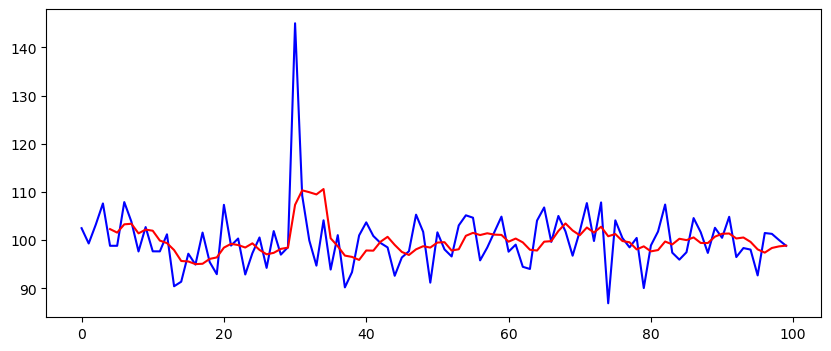

In [54]:
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
axes.plot(df_cnc.index, df_cnc["spindle_pressure"], color="blue")
axes.plot(df_cnc.index, df_cnc["pressure_ma"], color="red")
plt.show()

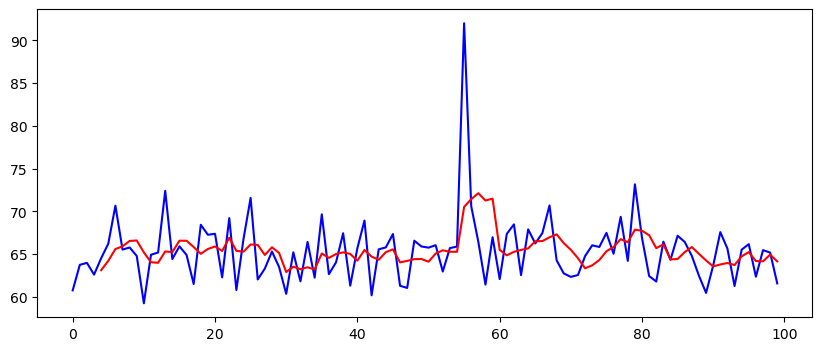

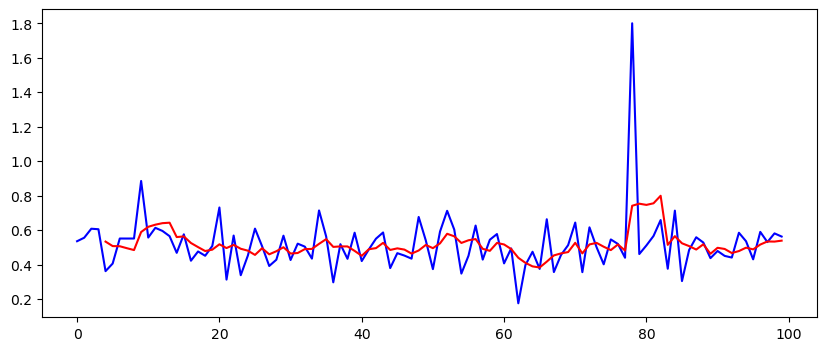

In [55]:
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
axes.plot(df_cnc.index, df_cnc["spindle_temp"], color="blue")
axes.plot(df_cnc.index, df_cnc["temp_ma"], color="red")
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(10, 4))
axes.plot(df_cnc.index, df_cnc["vibration"], color="blue")
axes.plot(df_cnc.index, df_cnc["vibration_ma"], color="red")
plt.show()

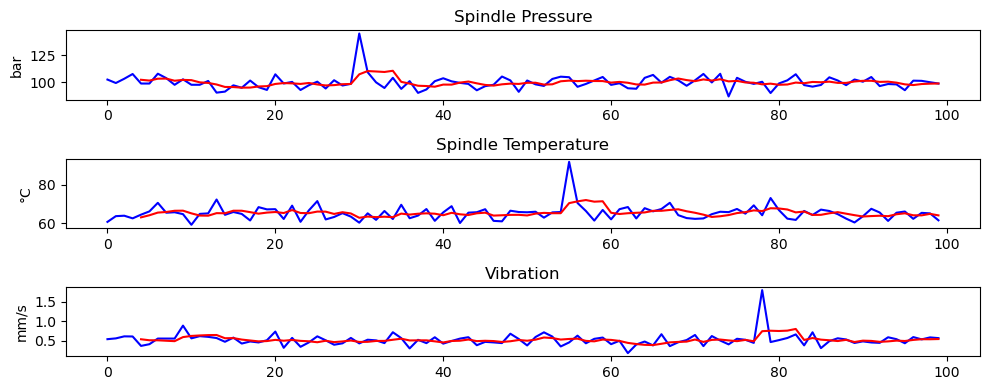

In [57]:
fig, axes = plt.subplots(3, 1, figsize=(10, 4))
axes[0].plot(df_cnc.index, df_cnc["spindle_pressure"], color="blue")
axes[0].plot(df_cnc.index, df_cnc["pressure_ma"], color="red")
axes[0].set_title("Spindle Pressure")
axes[0].set_ylabel("bar")
axes[1].plot(df_cnc.index, df_cnc["spindle_temp"], color="blue")
axes[1].plot(df_cnc.index, df_cnc["temp_ma"], color="red")
axes[1].set_title("Spindle Temperature")
axes[1].set_ylabel("°C")
axes[2].plot(df_cnc.index, df_cnc["vibration"], color="blue")
axes[2].plot(df_cnc.index, df_cnc["vibration_ma"], color="red")
axes[2].set_title("Vibration")
axes[2].set_ylabel("mm/s")
plt.tight_layout()
plt.savefig("cnc_overview.png")
plt.show()

In [58]:
plt.savefig("moving_average_plot.png")

<Figure size 640x480 with 0 Axes>